# EDA of heart data

In [385]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [386]:
df = pd.read_csv("D:\EDA model\data\heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [387]:
print(f" Shape : {df.shape} ")
print(f" Columns : {df.columns} ")

 Shape : (918, 12) 
 Columns : Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object') 


In [388]:
df.isnull().sum()
# data has not null values

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [389]:
df.duplicated().sum()
# no duplicates

np.int64(0)

In [390]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [391]:
catagory = ["Sex" , "ChestPainType" ,"RestingECG" ,"ExerciseAngina" , "ST_Slope" ,"HeartDisease"]
for col in catagory:
    print(df[col].value_counts())


Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [392]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

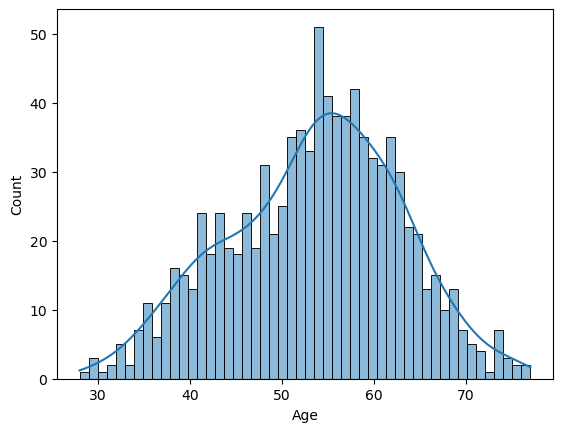

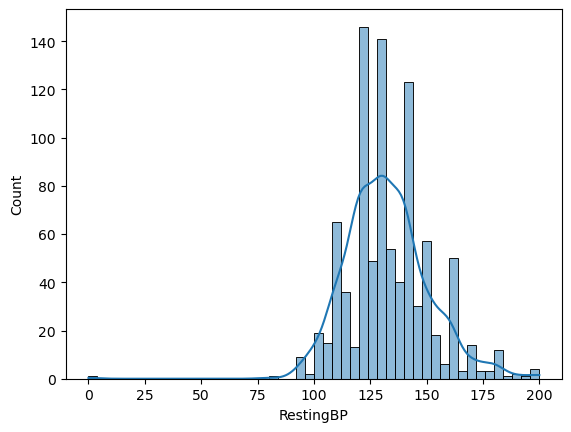

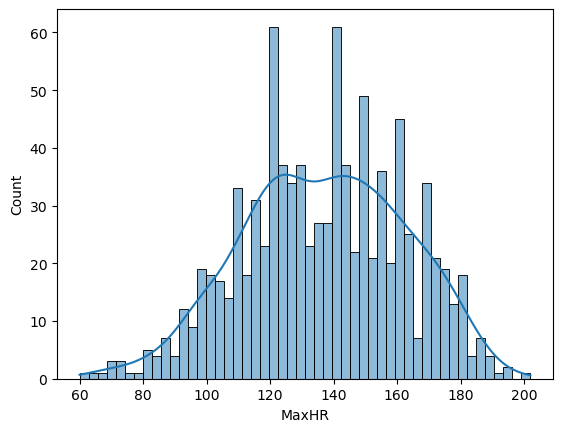

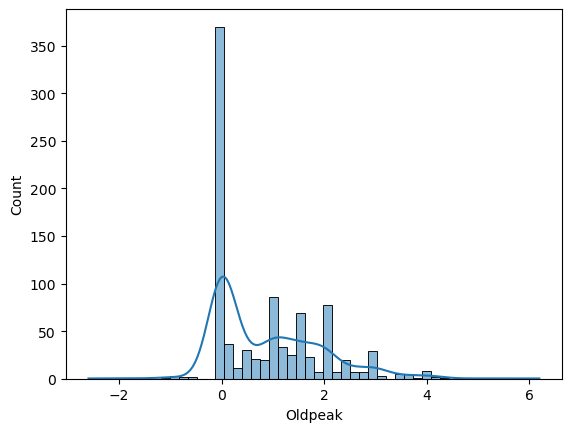

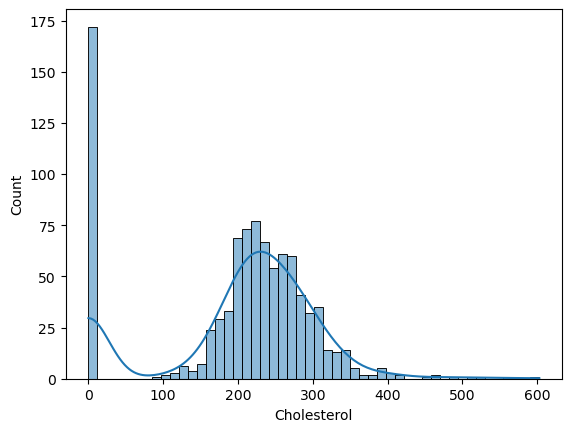

In [393]:
numeric_col = ["Age", "RestingBP" , "MaxHR" , "Oldpeak" ,'Cholesterol' ]
for col in numeric_col :
    plt.figure()
    sns.histplot(df[col],bins= 50 , kde = True ,legend = True )

<Axes: xlabel='RestingBP', ylabel='Count'>

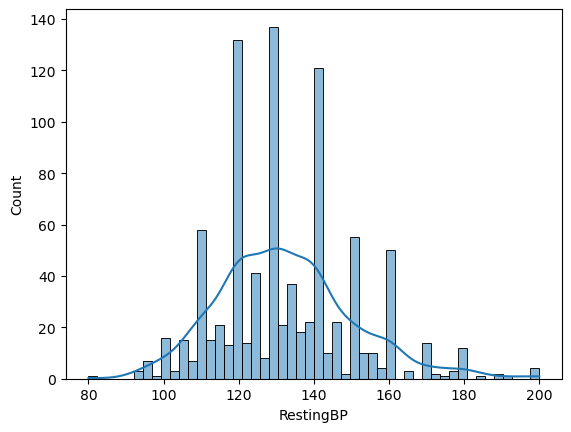

In [394]:
# drop the value where BP is zero
# we can fill with mean also
df = df.drop(df[df["RestingBP"] == 0].index)
df.shape
plt.figure()
sns.histplot(df["RestingBP"],bins= 50 , kde = True ,legend = True )

<Axes: xlabel='Cholesterol', ylabel='Count'>

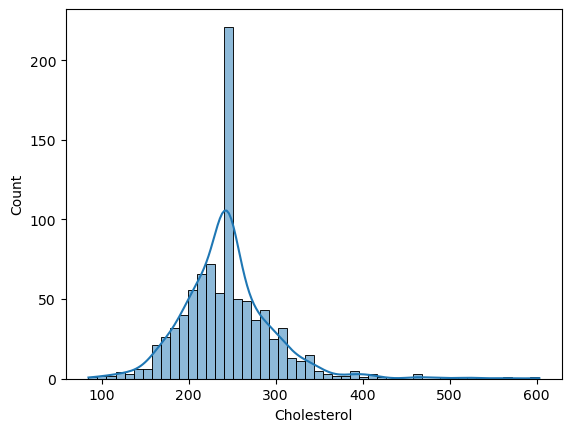

In [395]:
df_nonzero_col = df.drop(df[df["Cholesterol"] == 0].index)
df_nonzero_col["Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0,244)
plt.figure()
sns.histplot(df["Cholesterol"],bins= 50 , kde = True ,legend = True)

<Axes: xlabel='Sex', ylabel='count'>

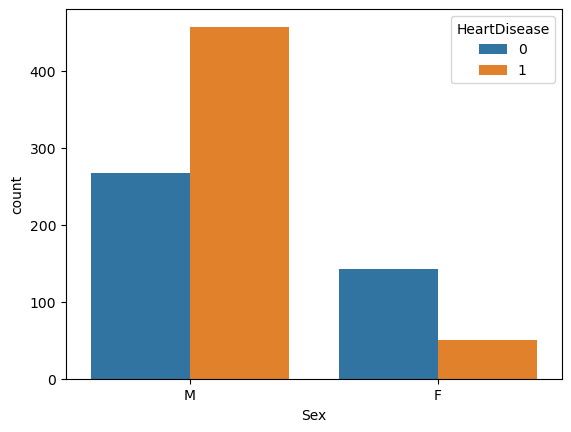

In [396]:
#count plot
sns.countplot(x = df["Sex"] , hue= df["HeartDisease"])

<Axes: xlabel='ChestPainType', ylabel='count'>

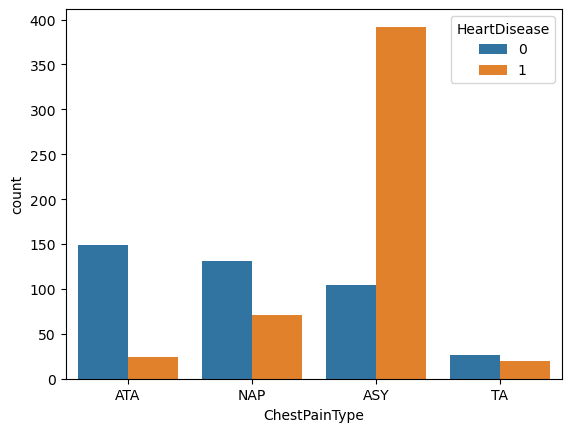

In [397]:
sns.countplot(x = df["ChestPainType"] , hue= df["HeartDisease"])

<Axes: xlabel='ST_Slope', ylabel='count'>

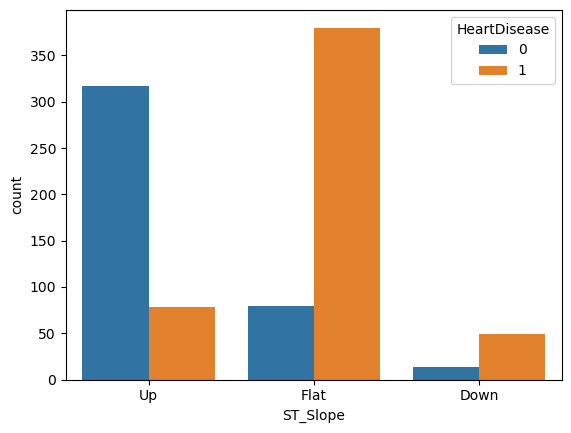

In [398]:
sns.countplot(x = df["ST_Slope"], hue= df["HeartDisease"])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

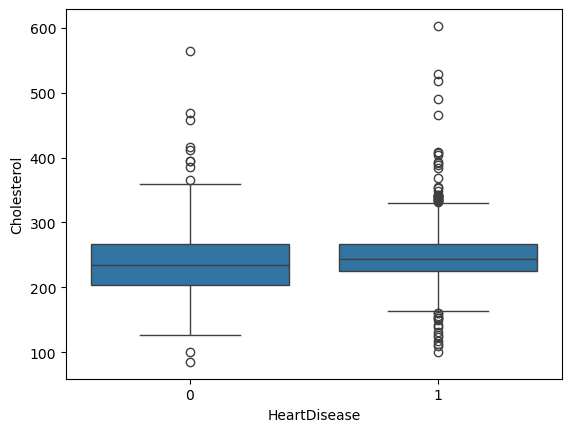

In [399]:
# Outlier by boxplot

sns.boxplot(y = df["Cholesterol"] , x = df["HeartDisease"] )

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

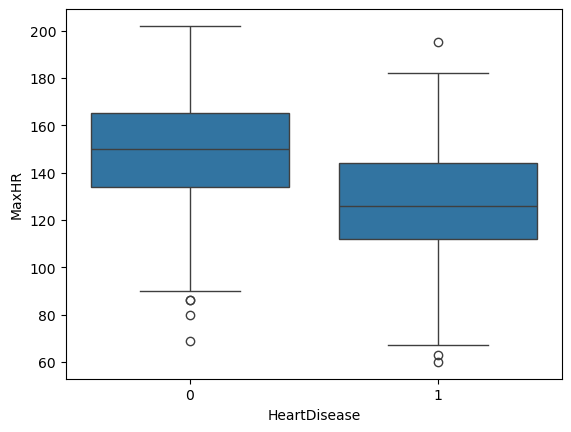

In [400]:
# Outlier by boxplot

sns.boxplot(y = df["MaxHR"] , x = df["HeartDisease"] )

<Axes: >

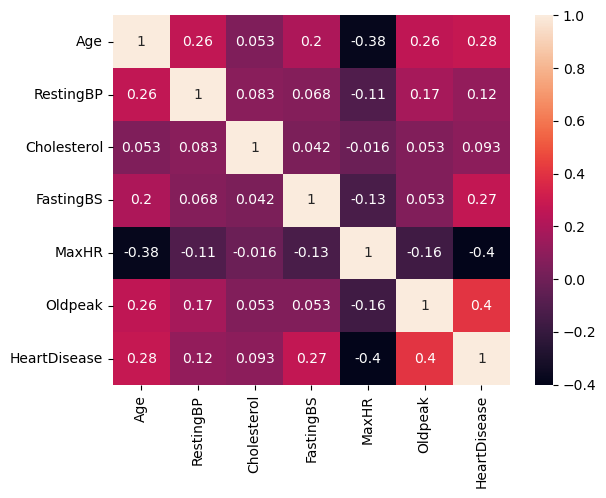

In [401]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data preprocessing

In [402]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [408]:
df_cleaned = df.copy()
df_cleaned

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [414]:
df_cleaned = pd.get_dummies(data =df_cleaned, drop_first=True)

In [420]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
#now all data are ready for modeling

# scaling

In [424]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()

df_cleaned[numeric_col] = scaler.fit_transform(df_cleaned[numeric_col])
df_cleaned

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,Sex_M,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.432206,0.414627,0.834288,0,1.383339,-0.726919,0,1,0,0,1,1,0,0,0,1
1,-0.478057,1.526360,-1.210026,0,0.754736,0.283058,1,0,1,0,0,1,0,0,1,0
2,-1.750256,-0.141240,0.721757,0,-1.523953,-0.726919,0,1,0,0,1,0,1,0,0,1
3,-0.584074,0.303453,-0.572350,0,-1.131075,0.283058,1,0,0,0,0,1,0,1,1,0
4,0.052026,0.970493,-0.928698,0,-0.581047,-0.726919,0,0,1,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902124,-1.252973,0.365409,0,-0.188170,0.283058,1,0,0,1,1,1,0,0,1,0
914,1.536257,0.636973,-0.966209,1,0.165420,2.303011,1,0,0,0,1,1,0,0,1,0
915,0.370075,-0.141240,-2.129030,0,-0.856061,0.283058,1,0,0,0,1,1,0,1,1,0
916,0.370075,-0.141240,-0.159736,0,1.461915,-0.726919,1,1,0,0,0,0,0,0,1,0


In [429]:
df_cleaned.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'Sex_M', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

# feature selection 

In [439]:
df_cleaned.corr(numeric_only=True)["HeartDisease"].sort_values(ascending=False)

HeartDisease         1.000000
ST_Slope_Flat        0.553700
ExerciseAngina_Y     0.495490
Oldpeak              0.392298
Sex_M                0.305118
Age                  0.282012
FastingBS            0.267994
RestingBP            0.117990
RestingECG_ST        0.103067
Cholesterol          0.092636
ChestPainType_TA    -0.054591
RestingECG_Normal   -0.092452
ChestPainType_NAP   -0.215311
MaxHR               -0.401410
ChestPainType_ATA   -0.401680
ST_Slope_Up         -0.621843
Name: HeartDisease, dtype: float64

In [443]:
from sklearn.feature_selection import mutual_info_classif

X = df_cleaned.drop("HeartDisease", axis=1)
y = df_cleaned["HeartDisease"]

mi_scores = mutual_info_classif(X, y)

mi = pd.Series(mi_scores, index=X.columns)
mi.sort_values(ascending=False)

ST_Slope_Up          0.208134
ST_Slope_Flat        0.164630
ExerciseAngina_Y     0.149707
Oldpeak              0.108023
MaxHR                0.091603
Cholesterol          0.075990
ChestPainType_ATA    0.074004
Age                  0.041577
Sex_M                0.039883
FastingBS            0.033763
RestingBP            0.030377
ChestPainType_NAP    0.025414
RestingECG_ST        0.016055
RestingECG_Normal    0.000000
ChestPainType_TA     0.000000
dtype: float64

# modeling

In [514]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# data initialise
final_feature =['ST_Slope_Up','ST_Slope_Flat','ExerciseAngina_Y','Oldpeak',              
'MaxHR',"Cholesterol" ,"ChestPainType_ATA" ,"Age","Sex_M" ,"FastingBS",'RestingBP',
"ChestPainType_NAP","RestingECG_ST"]

X = df_cleaned[final_feature]
y = df_cleaned["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

#model
model1 = LogisticRegression(max_iter = 1000)
model2 = DecisionTreeClassifier(max_depth=10)


res1 = model1.fit(X_train,y_train)
prediction1 = res1.predict(X_test)

res2 = model2.fit(X_train,y_train)
prediction2 = res2.predict(X_test)

# model evalution

In [515]:
print("LogisticRegression")
from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:", precision_score(y_test, prediction1))
print("Recall:", recall_score(y_test, prediction1))
print("F1 Score:", f1_score(y_test, prediction1))

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, prediction1))

print("\nConfusion Matrix:\n", confusion_matrix(y_test,prediction1))

print("\nClassification Report:\n", classification_report(y_test, prediction1))
print("_"*10)

print("DecisionTreeClassifier")

print("Precision:", precision_score(y_test, prediction2))
print("Recall:", recall_score(y_test, prediction2))
print("F1 Score:", f1_score(y_test, prediction2))

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test,prediction2))

print("\nConfusion Matrix:\n", confusion_matrix(y_test,prediction2))

print("\nClassification Report:\n", classification_report(y_test, prediction2))

LogisticRegression
Precision: 0.9056603773584906
Recall: 0.8571428571428571
F1 Score: 0.8807339449541285
Accuracy: 0.8586956521739131

Confusion Matrix:
 [[62 10]
 [16 96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.83        72
           1       0.91      0.86      0.88       112

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.86      0.86       184

__________
DecisionTreeClassifier
Precision: 0.8
Recall: 0.7857142857142857
F1 Score: 0.7927927927927928
Accuracy: 0.75

Confusion Matrix:
 [[50 22]
 [24 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.69      0.68        72
           1       0.80      0.79      0.79       112

    accuracy                           0.75       184
   macro avg       0.74      0.74      0.74       184
weighted avg       